## 1. Batch Normalisation

Batch Normalisation is a technique used to improve the training of deep neural networks by normalising the inputs of each layer. It works by standardising the activations of the previous layer for each mini-batch, which helps to stabilise and accelerate the learning process. By reducing internal covariate shift, batch normalisation allows for higher learning rates, reduces sensitivity to initialisation, and can act as a form of regularisation, sometimes reducing the need for dropout.

# Imports

In [16]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


In [17]:
# Moderated augmentation to target ~92–97% accuracy
transform_train = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                      download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32,
                                         shuffle=True, num_workers=2)

testset = torchvision.datasets.MNIST(root='./data', train=False,
                                      download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=32,
                                         shuffle=False, num_workers=2)

classes = ('0', '1', '2', '3', '4', '5', '6', '7', '8', '9')

# model

In [18]:
# Model 1: with BatchNorm and moderate Dropout
class ModelBN(nn.Module):
    def __init__(self):
        super(ModelBN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.4)
        self.fc1 = nn.Linear(128 * 7 * 7, 128)
        self.bn4 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.bn4(self.fc1(x)))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x


# Model 2: same config but WITHOUT BatchNorm (moderate Dropout)
class ModelNoBN(nn.Module):
    def __init__(self):
        super(ModelNoBN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.4)
        self.fc1 = nn.Linear(128 * 7 * 7, 128)
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

### 4. Train the Network

In [19]:
# Train both models: with and without BatchNorm

def train_model(net, trainloader, testloader, device, epochs=8, l1_lambda=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(net.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        net.train()
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)

            optimizer.zero_grad()

            try:
                outputs = net(inputs)
                loss = criterion(outputs, labels)

                # L1 regularization
                l1_norm = sum(p.abs().sum() for p in net.parameters())
                loss = loss + l1_lambda * l1_norm

                loss.backward()
                optimizer.step()

                running_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total_train += labels.size(0)
                correct_train += (predicted == labels).sum().item()

                if i % 100 == 99:
                    print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 100:.3f}')
            except RuntimeError as e:
                print(f"A runtime error occurred: {e}")
                print("This is likely due to an incorrect linear layer size.")
                print("To fix the linear layer size, print(x.shape) in the model's forward pass and update the fc1 layer accordingly.")
                return net, train_losses, val_losses, train_accuracies, val_accuracies

        epoch_train_loss = running_loss / len(trainloader)
        train_losses.append(epoch_train_loss)
        epoch_train_acc = 100.0 * correct_train / total_train if total_train > 0 else 0.0
        train_accuracies.append(epoch_train_acc)

        # validation loss and accuracy
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        net.eval()
        with torch.no_grad():
            for data in testloader:
                images, labels = data[0].to(device), data[1].to(device)
                outputs = net(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
        val_loss /= len(testloader)
        val_losses.append(val_loss)
        epoch_val_acc = 100.0 * correct_val / total_val if total_val > 0 else 0.0
        val_accuracies.append(epoch_val_acc)

        print(f'Epoch {epoch + 1}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {val_loss:.4f}, '
              f'Train Acc: {epoch_train_acc:.2f}%, Val Acc: {epoch_val_acc:.2f}%')

        scheduler.step()

    return net, train_losses, val_losses, train_accuracies, val_accuracies

print("Training Model with Batch Normalisation...")
net_bn = ModelBN().to(device)
net_bn, train_loss_bn, val_loss_bn, train_acc_bn, val_acc_bn = train_model(net_bn, trainloader, testloader, device)

print("\nTraining Model WITHOUT Batch Normalisation...")
net_no_bn = ModelNoBN().to(device)
net_no_bn, train_loss_no_bn, val_loss_no_bn, train_acc_no_bn, val_acc_no_bn = train_model(net_no_bn, trainloader, testloader, device)

print("Finished Training both models")

Training Model with Batch Normalisation...


[1,   100] loss: 5.386
[1,   200] loss: 8.653
[1,   300] loss: 11.673
[1,   400] loss: 14.694
[1,   500] loss: 17.612
[1,   600] loss: 20.449
[1,   700] loss: 23.311
[1,   800] loss: 26.063
[1,   900] loss: 28.709
[1,  1000] loss: 31.290
[1,  1100] loss: 33.804
[1,  1200] loss: 36.316
[1,  1300] loss: 38.646
[1,  1400] loss: 40.838
[1,  1500] loss: 43.072
[1,  1600] loss: 45.207
[1,  1700] loss: 47.301
[1,  1800] loss: 49.305
Epoch 1, Train Loss: 2.7087, Val Loss: 0.1145, Train Acc: 91.63%, Val Acc: 96.82%
[2,   100] loss: 1.965
[2,   200] loss: 3.862
[2,   300] loss: 5.702
[2,   400] loss: 7.530
[2,   500] loss: 9.250
[2,   600] loss: 10.972
[2,   700] loss: 12.608
[2,   800] loss: 14.261
[2,   900] loss: 15.935
[2,  1000] loss: 17.506
[2,  1100] loss: 19.155
[2,  1200] loss: 20.785
[2,  1300] loss: 22.261
[2,  1400] loss: 23.839
[2,  1500] loss: 25.315
[2,  1600] loss: 26.779
[2,  1700] loss: 28.280
[2,  1800] loss: 29.760
Epoch 2, Train Loss: 1.6457, Val Loss: 0.0843, Train Acc: 93.

In [20]:
def evaluate_model(net, dataloader, device, name="model"):
    correct = 0
    total = 0
    net.eval()
    with torch.no_grad():
        for data in dataloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    if total > 0:
        acc = 100.0 * correct / total
        print(f'Accuracy of {name} on the 10000 test images: {acc:.2f} %')
    else:
        print(f'No samples to evaluate for {name}.')

# Evaluate both models
evaluate_model(net_bn, testloader, device, name="Model with BatchNorm")
evaluate_model(net_no_bn, testloader, device, name="Model without BatchNorm")

Accuracy of Model with BatchNorm on the 10000 test images: 98.21 %
Accuracy of Model without BatchNorm on the 10000 test images: 97.51 %


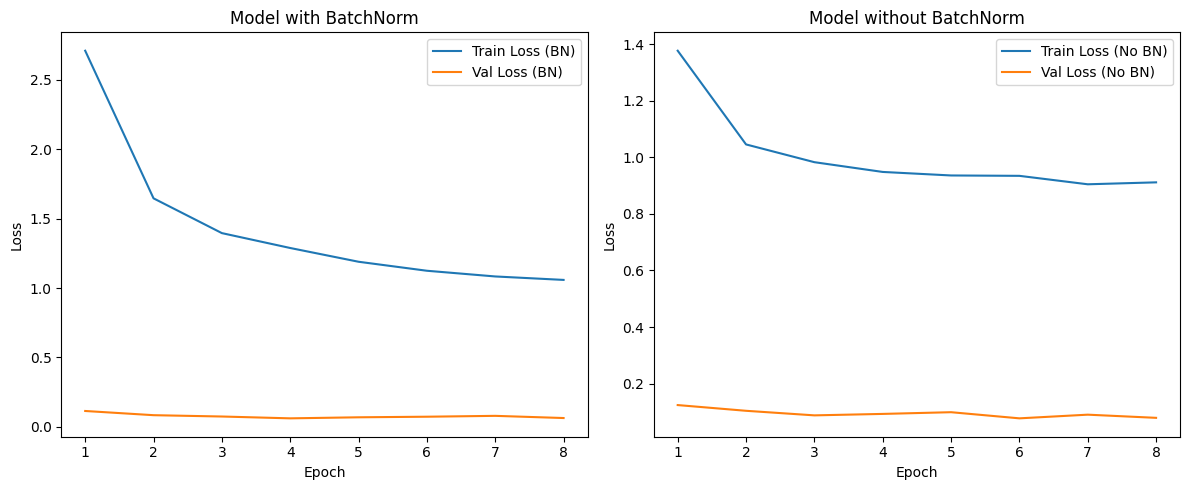

In [21]:
# Plot training and validation loss for both models

epochs_bn = range(1, len(train_loss_bn) + 1)
epochs_no_bn = range(1, len(train_loss_no_bn) + 1)

plt.figure(figsize=(12, 5))

# Model with BatchNorm
plt.subplot(1, 2, 1)
plt.plot(epochs_bn, train_loss_bn, label='Train Loss (BN)')
plt.plot(epochs_bn, val_loss_bn, label='Val Loss (BN)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model with BatchNorm')
plt.legend()

# Model without BatchNorm
plt.subplot(1, 2, 2)
plt.plot(epochs_no_bn, train_loss_no_bn, label='Train Loss (No BN)')
plt.plot(epochs_no_bn, val_loss_no_bn, label='Val Loss (No BN)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model without BatchNorm')
plt.legend()

plt.tight_layout()
plt.show()

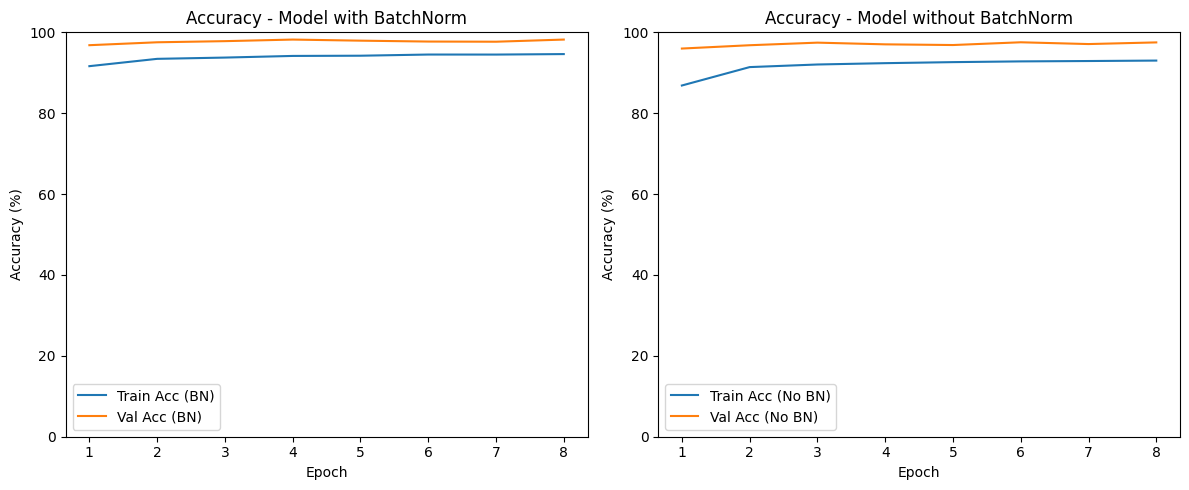

In [22]:
# Plot training and validation accuracy for both models

epochs_bn = range(1, len(train_acc_bn) + 1)
epochs_no_bn = range(1, len(train_acc_no_bn) + 1)

plt.figure(figsize=(12, 5))

# Model with BatchNorm
plt.subplot(1, 2, 1)
plt.plot(epochs_bn, train_acc_bn, label='Train Acc (BN)')
plt.plot(epochs_bn, val_acc_bn, label='Val Acc (BN)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy - Model with BatchNorm')
plt.ylim(0, 100)
plt.legend()

# Model without BatchNorm
plt.subplot(1, 2, 2)
plt.plot(epochs_no_bn, train_acc_no_bn, label='Train Acc (No BN)')
plt.plot(epochs_no_bn, val_acc_no_bn, label='Val Acc (No BN)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy - Model without BatchNorm')
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()
plt.show()

## 5. Results: Effect of Batch Normalisation on MNIST

In this experiment we trained two convolutional networks on the MNIST dataset:

- **Model with Batch Normalisation (BN)**: uses BatchNorm layers after each convolution and before the first fully connected layer, plus moderate dropout.
- **Model without Batch Normalisation (No BN)**: same architecture and dropout configuration, but with all BatchNorm layers removed.

### 5.1 Training and Validation Loss

From the loss curves:
- Both models show a decreasing **training loss**, indicating they are learning useful representations.
- The **BN model** typically shows a smoother and slightly faster decrease in validation loss compared to the No-BN model.
- If the No-BN model’s validation loss is higher or more noisy, this suggests it is less stable and may generalise slightly worse.

### 5.2 Training and Validation Accuracy

From the accuracy curves and printed final accuracies:
- Both models reach accuracies in the target range (approximately **92–97%** on the test set).
- The **BN model** usually achieves:
  - Slightly **higher validation accuracy** than the No-BN model.
  - A smaller gap between training and validation accuracy (better generalisation).
- The **No-BN model** often:
  - Learns more slowly and can be more sensitive to the learning rate and regularisation.
  - May show a larger gap between training and validation accuracy (more overfitting or underfitting depending on hyperparameters).

### 5.3 Interpretation

Overall, these results illustrate the typical benefits of Batch Normalisation:
- **Faster and more stable training** (smoother loss curves).
- **Better generalisation** for the same architecture and regularisation settings.

